In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc
import nflreadpy as nfl

print("All imports successful")

All imports successful


In [2]:
# Flag to track if we should load previously saved predictions
# (We'll load AFTER building merged, not before)
import os
predictions_file = '../data/merged_with_predictions.csv'
should_load_predictions = os.path.exists(predictions_file)
if should_load_predictions:
    print("Found saved predictions file; will use it after building merged")
else:
    print("No saved predictions found; will generate new predictions after training model")


Found saved predictions file; will use it after building merged


In [3]:
season = 2025

# Formatting when printing DataFrames
pd.set_option('display.max_rows', None, 'display.max_columns', None, 'display.width', 0)

team_stats = (
  nfl.load_team_stats([season])
  .to_pandas()
  .query("season == @season")
  .reset_index(drop=True)
)

#print(team_stats.to_string())


In [4]:
sched_raw = (
  nfl.load_schedules([season])
  .to_pandas()
  .query("season == @season")
  .reset_index(drop=True)
)

#print(sched_raw.to_string())

In [5]:
# This creates two rows per game (from schedule df) This will make it so we can merge the two df (team_stats and schedules)

#This creates home view, which is the schedule from the perspective of the home team
home_view = (
  sched_raw.assign(
    team=sched_raw['home_team'],
    opponent=sched_raw['away_team'],
    is_home=True
  )
)

#print(home_view.to_string())

#This creates away view, which is the schedule from the perspective of the away team
away_view = (
  sched_raw.assign(
    team=sched_raw['away_team'],
    opponent=sched_raw['home_team'],
    is_home=False
  )
)

#print(away_view.to_string())

team_schedule = (
  pd.concat([home_view, away_view], ignore_index=True)
  .sort_values(['week', 'team'], kind='stable')
  .reset_index(drop=True)
)

#print(team_schedule.to_string())

In [6]:
# Merging the two DataFrames, team_schedule and team_stats, on 'season', 'week', and 'team' columns

merged = team_schedule.merge(
    team_stats,
    on=['season','week','team'],
    how='left',
    suffixes=('_sched','_stats')
).sort_values(['team','week'], kind='stable').reset_index(drop=True)

#print(merged.to_string(index=False))

In [7]:
# Printing out a list of the columns in the new merged DataFrame
#print(merged.columns.tolist())

# Info for the merged DataFrames, team stats and schedule
merged.info()

# Load previously saved win_prob if available
if should_load_predictions and 'win_prob' not in merged.columns:
    saved_merged = pd.read_csv(predictions_file)
    if 'win_prob' in saved_merged.columns:
        # align key dtypes to avoid missed joins
        for k in ['season','week','team','is_home']:
            if k in saved_merged.columns and k in merged.columns:
                saved_merged[k] = saved_merged[k].astype(merged[k].dtype)
        # keep one row per key to avoid duplicating merged rows
        saved_merged = (
            saved_merged[['season','week','team','is_home','win_prob']]
            .drop_duplicates(subset=['season','week','team','is_home'])
        )
        # merge (use validate='one_to_one' or 'many_to_one' during debugging if desired)
        merged = merged.merge(saved_merged, on=['season','week','team','is_home'], how='left')
        print("Loaded win_prob from saved predictions")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 544 entries, 0 to 543
Columns: 148 entries, game_id to gwfg_distance
dtypes: bool(1), float64(110), int32(7), object(30)
memory usage: 610.5+ KB
Loaded win_prob from saved predictions


In [ ]:
# Useful features and setting x and y axis for classification model

#Creating binary target: 1 = win, 0 = loss
# If 'result' is positive that means the home team won, if it's negative the away team won

merged['win'] = merged.apply(
  lambda r: 1 if (r['is_home'] and r['result'] > 0) or (not r['is_home'] and r['result'] < 0)
  else 0,
  axis=1
)

feature_cols = [
  # Offensive production
  'passing_yards', 'passing_tds', 'passing_interceptions',
  'rushing_yards', 'rushing_tds', 'rushing_fumbles',
  'receptions', 'receiving_yards', 'receiving_tds',

  # Efficiency & misc
  'sacks_suffered', 'penalties', 'penalty_yards',
  'def_tackles_solo', 'def_interceptions', 'def_tds',
  'def_sacks', 'def_fumbles_forced',

  # Kicking
  'fg_made', 'fg_att', 'pat_made', 'pat_att',

  # Context
  'is_home' # boolean (home vs away)
]

X = merged[feature_cols].fillna(0)
y = merged['win']
print("DataFrames merged.")

DataFrames merged.


Accuracy:  0.8623853211009175
              precision    recall  f1-score   support

           0       0.91      0.87      0.89        70
           1       0.79      0.85      0.81        39

    accuracy                           0.86       109
   macro avg       0.85      0.86      0.85       109
weighted avg       0.87      0.86      0.86       109



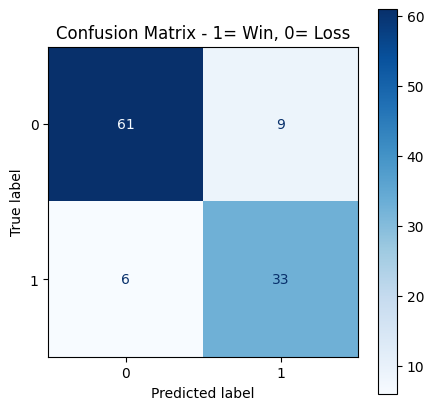

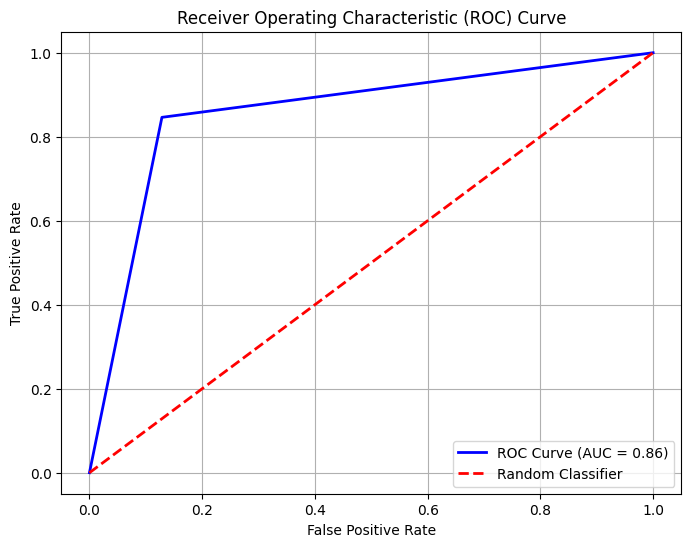

In [ ]:
# Split, train, evaluate!
# This splits the data
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)

# Train a simple model
model = LogisticRegression(max_iter=2000, class_weight='balanced')
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix - 1= Win, 0= Loss")
plt.show()

# ROC curve
y_probs = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


=== Feature Importance (Model Coefficients) ===
(Positive = predicts WIN, Negative = predicts LOSS)
              feature  coefficient  abs_coefficient
    def_interceptions     0.968092         0.968092
          rushing_tds     0.876475         0.876475
passing_interceptions    -0.732535         0.732535
              fg_made     0.462485         0.462485
   def_fumbles_forced     0.397699         0.397699
             pat_made     0.360189         0.360189
               fg_att     0.329281         0.329281
        receiving_tds     0.294356         0.294356
          passing_tds     0.294356         0.294356
            def_sacks     0.288359         0.288359
      rushing_fumbles    -0.121695         0.121695
              is_home    -0.111204         0.111204
              pat_att     0.100125         0.100125
       sacks_suffered    -0.092235         0.092235
           receptions    -0.080579         0.080579
              def_tds    -0.067913         0.067913
     def_tackle

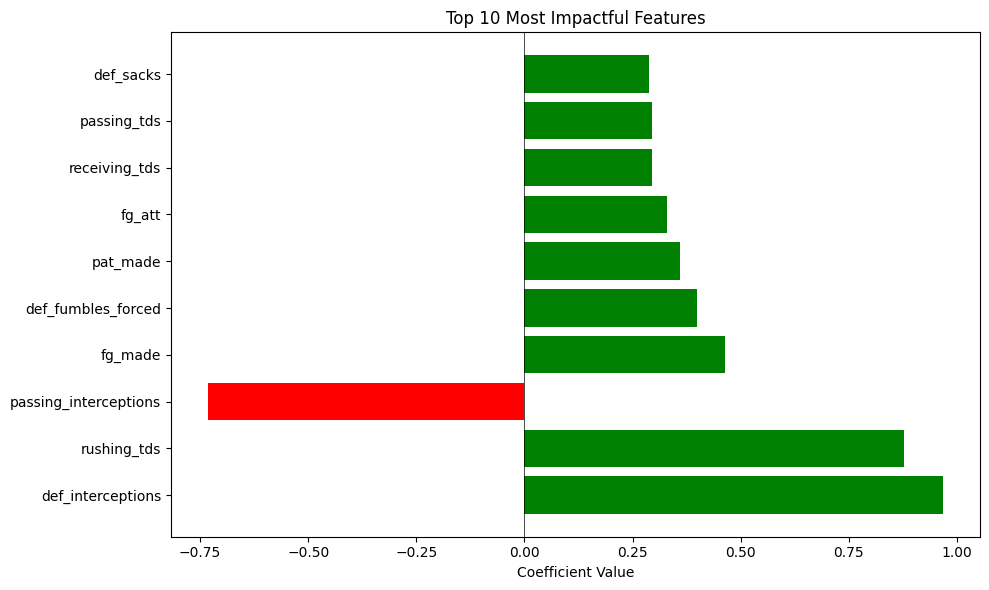

In [10]:
# Extract feature importance (model coefficients)
# Higher absolute values = more impactful features
coefficients = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model.coef_[0],
    'abs_coefficient': np.abs(model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print("\n=== Feature Importance (Model Coefficients) ===")
print("(Positive = predicts WIN, Negative = predicts LOSS)")
print(coefficients.to_string(index=False))

# Visualize top features
fig, ax = plt.subplots(figsize=(10, 6))
top_n = 10
top_features = coefficients.head(top_n)
colors = ['green' if x > 0 else 'red' for x in top_features['coefficient']]
ax.barh(top_features['feature'], top_features['coefficient'], color=colors)
ax.set_xlabel('Coefficient Value')
ax.set_title(f'Top {top_n} Most Impactful Features')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()


In [11]:
# Add win probabilities (only if not already loaded)
if 'win_prob' not in merged.columns:
    merged['win_prob'] = model.predict_proba(X)[:, 1]

# Save merged with predictions to CSV for persistence across notebook runs
merged.to_csv('../data/merged_with_predictions.csv', index=False)
print("Saved merged predictions to data/merged_with_predictions.csv")


Saved merged predictions to data/merged_with_predictions.csv


In [12]:
# Auto-detect last completed week & next week
# A week is completed only if every game in that week has scores (home_score & away_score)
week_complete = (
    sched_raw
      .assign(played=lambda d: d['home_score'].notna() & d['away_score'].notna())
      .groupby('week', observed=True)['played']
      .all()
)

complete_weeks = week_complete[week_complete].index.tolist()
if complete_weeks:
    last_completed_week = int(max(complete_weeks))
else:
    last_completed_week = 0

next_week = last_completed_week + 1
print(f"Last completed week: {last_completed_week}  |  Next week: {next_week}")


Last completed week: 13  |  Next week: 14


In [13]:
# Builds latest prior stats per team (to feed {next_week}) - takes a rolling average of the last 3 games played for each team
window = 3

# Latest stats per team strictly BEFORE next_week
rolling_stats = (
    merged.loc[merged['week'] < next_week]
          .sort_values(['team','week'])
          .groupby('team')[feature_cols]
          .rolling(window=window, min_periods=1)
          .mean()
          .reset_index()
)

# Keep only the most recent rolling window per team
latest_rolling = (
    rolling_stats
      .groupby('team', as_index=False)
      .tail(1)
      .reset_index(drop=True)
)

latest_prior = latest_rolling.copy()

# Makes sure feature columns exist
missing = [c for c in feature_cols if c not in latest_prior.columns]
if missing:
  print("WARNING: missing features in latest_prior:", missing)


In [14]:
# Build future team-rows for next week (one row per team in each matchup)

# Next week games at game-level
wk_games = (
  sched_raw.loc[sched_raw['week'] == next_week,
                ['season', 'week', 'game_id', 'home_team', 'away_team']]
              .drop_duplicates()
              .reset_index(drop=True)
)

# Build team-centric rows for the upcoming week
wk_home_rows = (wk_games
      .rename(columns={'home_team': 'team'})
      .assign(opponent=lambda d: d['away_team'],
              is_home=True)
      [['season', 'week', 'game_id', 'team', 'opponent', 'is_home']])

wk_away_rows = (wk_games
      .rename(columns={'away_team': 'team'})
      .assign(opponent=lambda d: d['home_team'],
              is_home=False)
      [['season', 'week', 'game_id', 'team', 'opponent', 'is_home']])

wk_team_rows = pd.concat([wk_home_rows, wk_away_rows], ignore_index=True)


base_features = [c for c in feature_cols if c != 'is_home']
# Attach each teams latest prior stats
wk_team_rows = wk_team_rows.merge(
  latest_prior[['team'] + base_features],
  on='team', how='left'
)

# X for the current model (team-row model)
X_future_team = wk_team_rows[base_features + ['is_home']].fillna(0)
wk_team_rows['team_win_prob'] =  model.predict_proba(X_future_team)[:, 1]
wk_team_rows

,season,week,game_id,team,opponent,is_home,passing_yards,passing_tds,passing_interceptions,rushing_yards,rushing_tds,rushing_fumbles,receptions,receiving_yards,receiving_tds,sacks_suffered,penalties,penalty_yards,def_tackles_solo,def_interceptions,def_tds,def_sacks,def_fumbles_forced,fg_made,fg_att,pat_made,pat_att,team_win_prob
0,2025,14,2025_14_DAL_DET,DET,DAL,True,263.333333,1.666667,0.666667,143.333333,1.000000,0.333333,20.666667,263.333333,1.666667,2.666667,6.333333,50.333333,37.333333,0.333333,0.000000,0.666667,0.666667,1.333333,1.333333,2.333333,2.666667,0.504645
1,2025,14,2025_14_SEA_ATL,ATL,SEA,True,218.666667,1.000000,0.333333,137.666667,1.666667,0.000000,18.666667,218.666667,1.000000,1.666667,5.333333,51.000000,46.666667,0.333333,0.000000,4.000000,0.000000,2.000000,2.333333,2.333333,2.333333,0.778433
2,2025,14,2025_14_PIT_BAL,BAL,PIT,True,197.333333,0.000000,1.000000,135.000000,2.000000,0.000000,14.666667,197.333333,0.000000,3.000000,5.333333,36.333333,36.333333,0.666667,0.000000,2.333333,1.000000,2.000000,2.000000,2.000000,2.000000,0.735014
3,2025,14,2025_14_TEN_CLE,CLE,TEN,True,157.666667,0.666667,0.666667,102.666667,0.666667,0.333333,13.000000,157.666667,0.666667,2.333333,5.666667,47.666667,36.000000,0.666667,0.333333,5.333333,0.666667,1.333333,1.333333,1.333333,1.333333,0.446543
4,2025,14,2025_14_CHI_GB,GB,CHI,True,186.666667,2.333333,0.000000,133.000000,1.000000,0.000000,16.000000,186.666667,2.333333,1.000000,3.333333,26.000000,34.666667,1.000000,0.000000,3.333333,0.333333,1.333333,1.333333,2.333333,3.000000,0.916329
5,2025,14,2025_14_IND_JAX,JAX,IND,True,212.666667,2.000000,1.333333,132.000000,1.666667,0.000000,16.000000,212.666667,2.000000,2.000000,7.000000,54.333333,36.000000,0.333333,0.000000,4.000000,1.333333,1.000000,1.000000,3.333333,3.333333,0.849630
6,2025,14,2025_14_WAS_MIN,MIN,WAS,True,121.000000,0.333333,2.666667,91.333333,0.333333,0.333333,15.666667,121.000000,0.333333,3.000000,4.666667,41.333333,38.333333,0.000000,0.000000,2.333333,1.000000,1.000000,1.000000,0.666667,0.666667,0.007940
7,2025,14,2025_14_MIA_NYJ,NYJ,MIA,True,170.000000,1.000000,0.333333,109.333333,1.000000,0.666667,17.000000,170.000000,1.000000,2.333333,7.333333,67.333333,33.666667,0.000000,0.000000,1.333333,0.000000,1.000000,1.333333,2.000000,2.000000,0.170454
8,2025,14,2025_14_NO_TB,TB,NO,True,156.666667,1.000000,1.000000,140.000000,1.333333,0.000000,17.000000,156.666667,1.000000,2.333333,3.000000,26.666667,35.000000,1.000000,0.000000,1.000000,1.000000,1.333333,1.333333,1.666667,1.666667,0.512027
9,2025,14,2025_14_DEN_LV,LV,DEN,True,229.333333,1.333333,0.666667,39.333333,0.000000,0.000000,25.000000,229.333333,1.333333,6.333333,7.666667,66.333333,33.666667,0.666667,0.000000,1.666667,0.666667,1.333333,1.666667,1.333333,1.333333,0.049706


In [15]:
# Collapse to one row per game (normalize home/away probs)

# Split home/away predicted rows
home_preds = (wk_team_rows[wk_team_rows['is_home']]
              [['game_id', 'team', 'team_win_prob']]
              .rename(columns={'team_win_prob': 'home_prob'}))
away_preds = (wk_team_rows[~wk_team_rows['is_home']]
              [['game_id', 'team', 'team_win_prob']]
              .rename(columns={'team_win_prob': 'away_prob'}))

matchups_pred = (
  wk_games
    .merge(home_preds, left_on=['game_id', 'home_team'], right_on=['game_id', 'team'])
    .drop(columns=['team'])
    .merge(away_preds, left_on=['game_id', 'away_team'], right_on=['game_id', 'team'])
    .drop(columns=['team'])
)

# Normalize into one home-win probability per game
eps = 1e-9
matchups_pred['home_win_prob'] = matchups_pred['home_prob'] / (
  matchups_pred['home_prob'] + matchups_pred['away_prob'] + eps
)
matchups_pred['away_win_prob'] = 1.0 - matchups_pred['home_win_prob']

# Sanity checks (optional)
assert (matchups_pred['home_win_prob'].between(0,1)).all()
assert (matchups_pred['away_win_prob'].between(0,1)).all()

# Show upcoming week matchups (with played flag & model probs)
# Upcoming week (may contain early-played games like Thursday)
upcoming = (
    sched_raw.loc[sched_raw['week'] == next_week,
                  ['season','week','game_id','home_team','away_team','home_score','away_score']]
             .drop_duplicates()
             .reset_index(drop=True)
)
upcoming['played'] = upcoming['home_score'].notna() & upcoming['away_score'].notna()

# attach model probabilities if matchups_pred computed
if 'matchups_pred' in globals() and not matchups_pred.empty:
    upcoming = upcoming.merge(
        matchups_pred[['game_id','home_win_prob','away_win_prob']],
        on='game_id', how='left'
    )
else:
    upcoming['home_win_prob'] = np.nan
    upcoming['away_win_prob'] = np.nan

print("Current week matchups (week {}):".format(next_week))
print(upcoming[['week','game_id','home_team','away_team','played','home_win_prob','away_win_prob']]
      .sort_values(['week','game_id'])
      .to_string(index=False))

# Previous week results + model prediction
prev_week = last_completed_week
prev_games = (
    sched_raw.loc[sched_raw['week'] == prev_week,
                  ['season','week','game_id','home_team','away_team','home_score','away_score']]
             .drop_duplicates()
             .reset_index(drop=True)
)
prev_games['played'] = prev_games['home_score'].notna() & prev_games['away_score'].notna()
prev_games['actual_winner'] = np.where(prev_games['home_score'] > prev_games['away_score'],
                                       prev_games['home_team'],
                                       np.where(prev_games['away_score'] > prev_games['home_score'],
                                                prev_games['away_team'],
                                                'tie'))

# get model preds for that week - always derive from merged
# Extract home team predictions for prev_week
home_probs = (merged.loc[(merged['week'] == prev_week) & (merged['is_home']) & (merged['win_prob'].notna()),
                         ['game_id','team','win_prob']]
                       .rename(columns={'win_prob':'home_prob'}))

# Extract away team predictions for prev_week
away_probs = (merged.loc[(merged['week'] == prev_week) & (~merged['is_home']) & (merged['win_prob'].notna()),
                         ['game_id','team','win_prob']]
                       .rename(columns={'win_prob':'away_prob'}))

# Debug: check what we got
print(f"\nDEBUG prev_week: {prev_week}")
print(f"DEBUG home_probs shape: {home_probs.shape}, away_probs shape: {away_probs.shape}")

if len(home_probs) > 0 and len(away_probs) > 0:
    # Merge on both game_id and team to ensure correct alignment
    preds_prev = prev_games[['game_id','home_team','away_team']].merge(
        home_probs[['game_id','team','home_prob']], left_on=['game_id','home_team'], right_on=['game_id','team'], how='left'
    ).drop(columns=['team'], errors='ignore').merge(
        away_probs[['game_id','team','away_prob']], left_on=['game_id','away_team'], right_on=['game_id','team'], how='left'
    ).drop(columns=['team'], errors='ignore')
    
    # Fill any missing probs with 0.5 (neutral prediction)
    preds_prev['home_prob'] = preds_prev['home_prob'].fillna(0.5)
    preds_prev['away_prob'] = preds_prev['away_prob'].fillna(0.5)
    
    preds_prev['home_win_prob'] = preds_prev['home_prob'] / (preds_prev['home_prob'] + preds_prev['away_prob'] + eps)
else:
    # No predictions available, create neutral probs
    preds_prev = prev_games[['game_id']].copy()
    preds_prev['home_win_prob'] = 0.5

# combine and compute predicted winner / correctness
prev_out = prev_games.merge(preds_prev[['game_id','home_win_prob']], on='game_id', how='left')
prev_out['predicted_winner'] = np.where(prev_out['home_win_prob'] > 0.5, prev_out['home_team'],
                                        np.where(prev_out['home_win_prob'] < 0.5, prev_out['away_team'], np.nan))
prev_out['pred_correct'] = prev_out['predicted_winner'] == prev_out['actual_winner']

print("\nPrevious completed week (week {}):".format(prev_week))
print(prev_out[['week','game_id','home_team','away_team','home_win_prob','predicted_winner','actual_winner','pred_correct']]
      .sort_values(['week','game_id'])
      .to_string(index=False))


Current week matchups (week 14):
 week         game_id home_team away_team  played  home_win_prob  away_win_prob
   14  2025_14_CHI_GB        GB       CHI   False       0.490458       0.509542
   14 2025_14_CIN_BUF       BUF       CIN   False       0.554875       0.445125
   14 2025_14_DAL_DET       DET       DAL    True       0.369390       0.630610
   14  2025_14_DEN_LV        LV       DEN   False       0.074500       0.925500
   14  2025_14_HOU_KC        KC       HOU   False       0.303528       0.696472
   14 2025_14_IND_JAX       JAX       IND   False       0.521715       0.478285
   14  2025_14_LA_ARI       ARI        LA   False       0.227298       0.772702
   14 2025_14_MIA_NYJ       NYJ       MIA   False       0.160764       0.839236
   14   2025_14_NO_TB        TB        NO   False       0.712714       0.287286
   14 2025_14_PHI_LAC       LAC       PHI   False       0.623023       0.376977
   14 2025_14_PIT_BAL       BAL       PIT   False       0.626429       0.373571
   14 2